# Phase 2 — ML: Repeat Purchase Prediction (Churn Model)

**Goal:** Predict whether a customer will make a second purchase based on their first order experience.  
**Why this matters:** Acquiring a new customer costs 5–7x more than retaining an existing one. Knowing *which* customers are likely to return lets you focus retention spend where it counts.

**What we build:**
- Feature engineering from the master table
- Logistic Regression baseline
- Random Forest (main model)
- Model evaluation: accuracy, precision, recall, ROC-AUC, confusion matrix
- Feature importance — *what actually drives repeat purchases?*
- Save the trained model for the Streamlit dashboard

---
**Prerequisite:** Run `01_eda.ipynb` first to generate `master.csv` inside your archive folder

## 1. Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
ACCENT = '#1a6cf5'
WARM   = '#e8593c'
GREEN  = '#2ecc71'

# ── PATHS — all files live in your archive folder ─────────────────────────────
DATA_DIR   = '/Users/adnan/Desktop/python coding/brazilian data set/'
MODELS_DIR = '/Users/adnan/Desktop/python coding/brazilian data set/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Imports ready ✓')
print(f'DATA_DIR   : {DATA_DIR}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'master.csv exists: {os.path.exists(os.path.join(DATA_DIR, "master.csv"))}')

Imports ready ✓
DATA_DIR   : /Users/adnan/Desktop/python coding/brazilian data set/
MODELS_DIR : /Users/adnan/Desktop/python coding/brazilian data set/models/
master.csv exists: True


---
## 2. Load Master Data

In [20]:
print(os.listdir())

['fig_category_revenue.png', 'rfm.csv', 'fig_feature_importance.png', 'fig_time_patterns.png', '.DS_Store', 'archive', 'fig_roc_curves.png', '02_ml_churn_fixed.ipynb', 'fig_model_comparison.png', 'fig_purchase_frequency.png', 'feature_importance.csv', '01_eda.ipynb', 'models', 'fig_delivery_vs_review.png', 'model_predictions.csv', 'master.csv', 'fig_payments.png', 'fig_geo_revenue.png', 'app.py', 'fig_confusion_matrix.png', 'fig_category_map.png', 'fig_permutation_importance.png', 'fig_monthly_revenue.png', 'fig_rfm_segments.png', 'fig_review_distribution.png', '03_forecasting.ipynb']


In [21]:
master = pd.read_csv('master.csv', parse_dates=['order_purchase_timestamp'])

print(f'Master loaded: {master.shape[0]:,} rows × {master.shape[1]} columns')
master.head(3)

Master loaded: 110,197 rows × 30 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days,...,product_weight_g,total_payment,payment_installments,payment_type,review_score,year,month,month_label,weekday,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,500.0,38.71,1.0,voucher,4.0,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,400.0,141.46,1.0,boleto,4.0,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,420.0,179.12,3.0,credit_card,5.0,2018,8,2018-08,Wednesday,8


---
## 3. Define the Target Variable

The ML question: **given everything we know about a customer's FIRST order, will they place a second order?**

- `target = 1` → customer placed more than one order (repeat buyer)
- `target = 0` → customer placed exactly one order (churned)

This is a **binary classification** problem.

In [22]:
# ── 3.1  Count orders per unique customer ─────────────────────────────────────
purchase_counts = (
    master.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)

# Target: 1 if customer made more than 1 purchase
purchase_counts['target'] = (purchase_counts['order_count'] > 1).astype(int)

repeat_rate = purchase_counts['target'].mean() * 100
print(f'Repeat buyers  (target=1): {purchase_counts["target"].sum():>6,}  ({repeat_rate:.1f}%)')
print(f'One-time buyers(target=0): {(purchase_counts["target"]==0).sum():>6,}  ({100-repeat_rate:.1f}%)')
print('\n⚠️  This is an imbalanced dataset — we will handle this during model training.')

Repeat buyers  (target=1):  2,801  (3.0%)
One-time buyers(target=0): 90,557  (97.0%)

⚠️  This is an imbalanced dataset — we will handle this during model training.


---
## 4. Feature Engineering

We build features using ONLY information from a customer's **first order**.  
Why? Because at prediction time (when we want to know if they'll return), we only have their first order to go on.

Using future order data would cause **data leakage** — the model would cheat by peeking at information it wouldn't have in reality.

In [23]:
# ── 4.1  Isolate each customer's first order ───────────────────────────────────
first_orders = (
    master.sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

print(f'First orders table: {first_orders.shape[0]:,} rows (one per unique customer)')

First orders table: 93,358 rows (one per unique customer)


In [24]:
# ── 4.2  Build feature set ─────────────────────────────────────────────────────
first_order_agg = (
    master.sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .agg(
        first_order_value   = ('price', 'first'),
        first_order_total   = ('price', lambda x: x.iloc[0] if len(x) > 0 else 0),
        first_freight       = ('freight_value', 'first'),
        first_review_score  = ('review_score', 'first'),
        first_delivery_days = ('delivery_days', 'first'),
        first_delivery_delta= ('delivery_delta', 'first'),
        first_payment_inst  = ('payment_installments', 'first'),
        first_category      = ('category', 'first'),
        customer_state      = ('customer_state', 'first'),
        first_hour          = ('hour', 'first'),
        first_month         = ('month', 'first'),
    )
    .reset_index()
)

# ── 4.3  Derived features ──────────────────────────────────────────────────────
first_order_agg['freight_ratio'] = (
    first_order_agg['first_freight'] /
    (first_order_agg['first_order_value'] + 1)
)
first_order_agg['was_early']      = (first_order_agg['first_delivery_delta'] > 0).astype(int)
first_order_agg['was_very_late']  = (first_order_agg['first_delivery_delta'] < -7).astype(int)

high_val_threshold = first_order_agg['first_order_value'].quantile(0.75)
first_order_agg['is_high_value']  = (first_order_agg['first_order_value'] >= high_val_threshold).astype(int)

first_order_agg['is_late_night_buyer'] = first_order_agg['first_hour'].apply(
    lambda h: 1 if h >= 20 or h <= 6 else 0
)

print('Feature engineering complete ✓')
print(f'Features created: {first_order_agg.shape[1]} columns')

Feature engineering complete ✓
Features created: 17 columns


In [25]:
# ── 4.4  Encode categorical features ──────────────────────────────────────────
top_categories = first_order_agg['first_category'].value_counts().head(20).index
first_order_agg['category_encoded'] = first_order_agg['first_category'].apply(
    lambda x: x if x in top_categories else 'other'
)

top_states = first_order_agg['customer_state'].value_counts().head(10).index
first_order_agg['state_encoded'] = first_order_agg['customer_state'].apply(
    lambda x: x if x in top_states else 'other'
)

df_encoded = pd.get_dummies(first_order_agg, columns=['category_encoded', 'state_encoded'], drop_first=True)
print(f'After encoding: {df_encoded.shape[1]} columns')

After encoding: 47 columns


In [26]:
# ── 4.5  Merge with target + select final features ────────────────────────────
df_model = df_encoded.merge(purchase_counts[['customer_unique_id','target']],
                            on='customer_unique_id', how='inner')

drop_cols = ['customer_unique_id', 'first_category', 'customer_state']
feature_cols = [c for c in df_model.columns
                if c not in drop_cols + ['target']
                and df_model[c].dtype in ['int64','float64','bool','uint8']]

X = df_model[feature_cols].copy()
y = df_model['target'].copy()
X = X.fillna(X.median())

print(f'Final feature matrix: {X.shape[0]:,} samples × {X.shape[1]} features')
print(f'Target distribution: {y.value_counts().to_dict()}')

Final feature matrix: 93,358 samples × 44 features
Target distribution: {0: 90557, 1: 2801}


---
## 5. Train / Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')
print(f'\nClass balance in train — 0: {(y_train==0).sum():,}  1: {(y_train==1).sum():,}')
print(f'Class balance in test  — 0: {(y_test==0).sum():,}  1: {(y_test==1).sum():,}')

# Scale for Logistic Regression (tree models don't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))
print('\nScaler saved ✓')

Train: 74,686 samples
Test:  18,672 samples

Class balance in train — 0: 72,445  1: 2,241
Class balance in test  — 0: 18,112  1: 560

Scaler saved ✓


---
## 6. Baseline Model — Logistic Regression

In [28]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(f'  Accuracy  : {accuracy_score(y_test, lr_preds):.4f}')
print(f'  Precision : {precision_score(y_test, lr_preds):.4f}')
print(f'  Recall    : {recall_score(y_test, lr_preds):.4f}')
print(f'  F1 Score  : {f1_score(y_test, lr_preds):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, lr_proba):.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['One-time','Repeat']))

=== LOGISTIC REGRESSION ===
  Accuracy  : 0.6013
  Precision : 0.0402
  Recall    : 0.5375
  F1 Score  : 0.0748
  ROC-AUC   : 0.5909

              precision    recall  f1-score   support

    One-time       0.98      0.60      0.75     18112
      Repeat       0.04      0.54      0.07       560

    accuracy                           0.60     18672
   macro avg       0.51      0.57      0.41     18672
weighted avg       0.95      0.60      0.73     18672



---
## 7. Main Model — Random Forest

In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print('Random Forest trained ✓')

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('\n=== RANDOM FOREST ===')
print(f'  Accuracy  : {accuracy_score(y_test, rf_preds):.4f}')
print(f'  Precision : {precision_score(y_test, rf_preds):.4f}')
print(f'  Recall    : {recall_score(y_test, rf_preds):.4f}')
print(f'  F1 Score  : {f1_score(y_test, rf_preds):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, rf_proba):.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=['One-time','Repeat']))

Random Forest trained ✓

=== RANDOM FOREST ===
  Accuracy  : 0.8905
  Precision : 0.0535
  Recall    : 0.1589
  F1 Score  : 0.0801
  ROC-AUC   : 0.5980

              precision    recall  f1-score   support

    One-time       0.97      0.91      0.94     18112
      Repeat       0.05      0.16      0.08       560

    accuracy                           0.89     18672
   macro avg       0.51      0.54      0.51     18672
weighted avg       0.94      0.89      0.92     18672



In [30]:
# ── 7.3  Cross-validation ─────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print('=== 5-FOLD CROSS-VALIDATION (Random Forest) ===')
print(f'  AUC per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean AUC     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\n💡 Low std means consistent performance across different data slices — good sign.')

=== 5-FOLD CROSS-VALIDATION (Random Forest) ===
  AUC per fold : ['0.5952', '0.6148', '0.5657', '0.6007', '0.6053']
  Mean AUC     : 0.5963 ± 0.0166

💡 Low std means consistent performance across different data slices — good sign.


---
## 8. Model Evaluation Visualizations

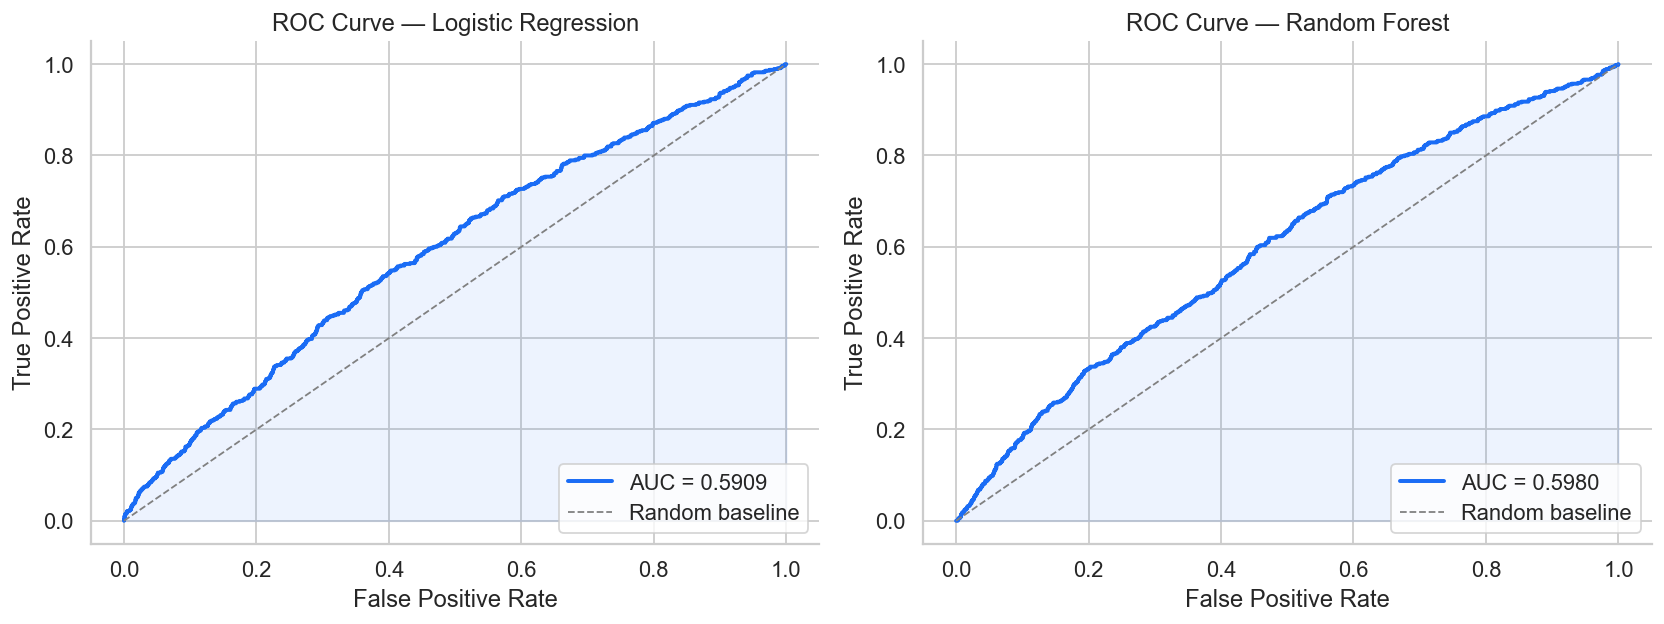

In [31]:
# ── 8.1  ROC Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, proba in [
    (axes[0], 'Logistic Regression', lr_proba),
    (axes[1], 'Random Forest',       rf_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=ACCENT, linewidth=2.2, label=f'AUC = {auc:.4f}')
    ax.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random baseline')
    ax.fill_between(fpr, tpr, alpha=0.08, color=ACCENT)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_roc_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

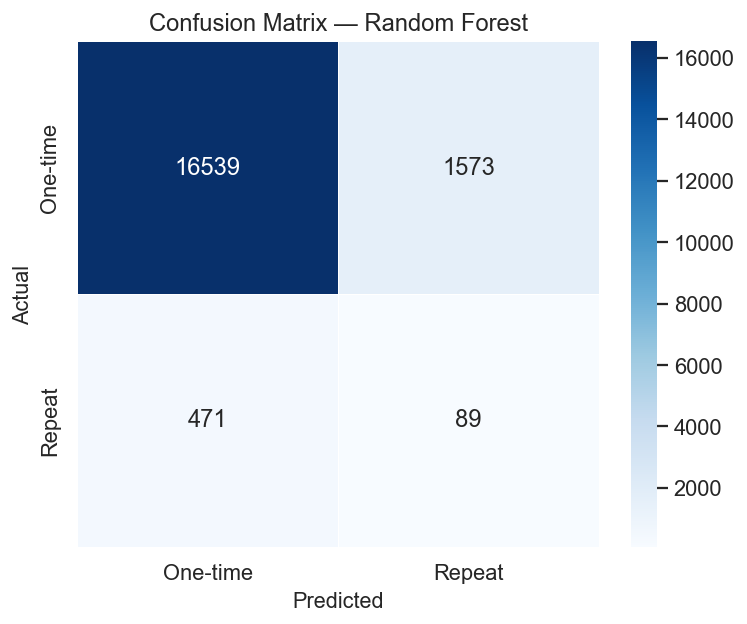

True Positives  (correctly predicted repeat buyer):    89
False Negatives (missed repeat buyers):                471
False Positives (predicted repeat, actually churned):  1,573
True Negatives  (correctly predicted one-time):        16,539


In [32]:
# ── 8.2  Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['One-time','Repeat'],
    yticklabels=['One-time','Repeat'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_confusion_matrix.png'), dpi=130, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly predicted repeat buyer):    {tp:,}')
print(f'False Negatives (missed repeat buyers):                {fn:,}')
print(f'False Positives (predicted repeat, actually churned):  {fp:,}')
print(f'True Negatives  (correctly predicted one-time):        {tn:,}')

---
## 9. Feature Importance

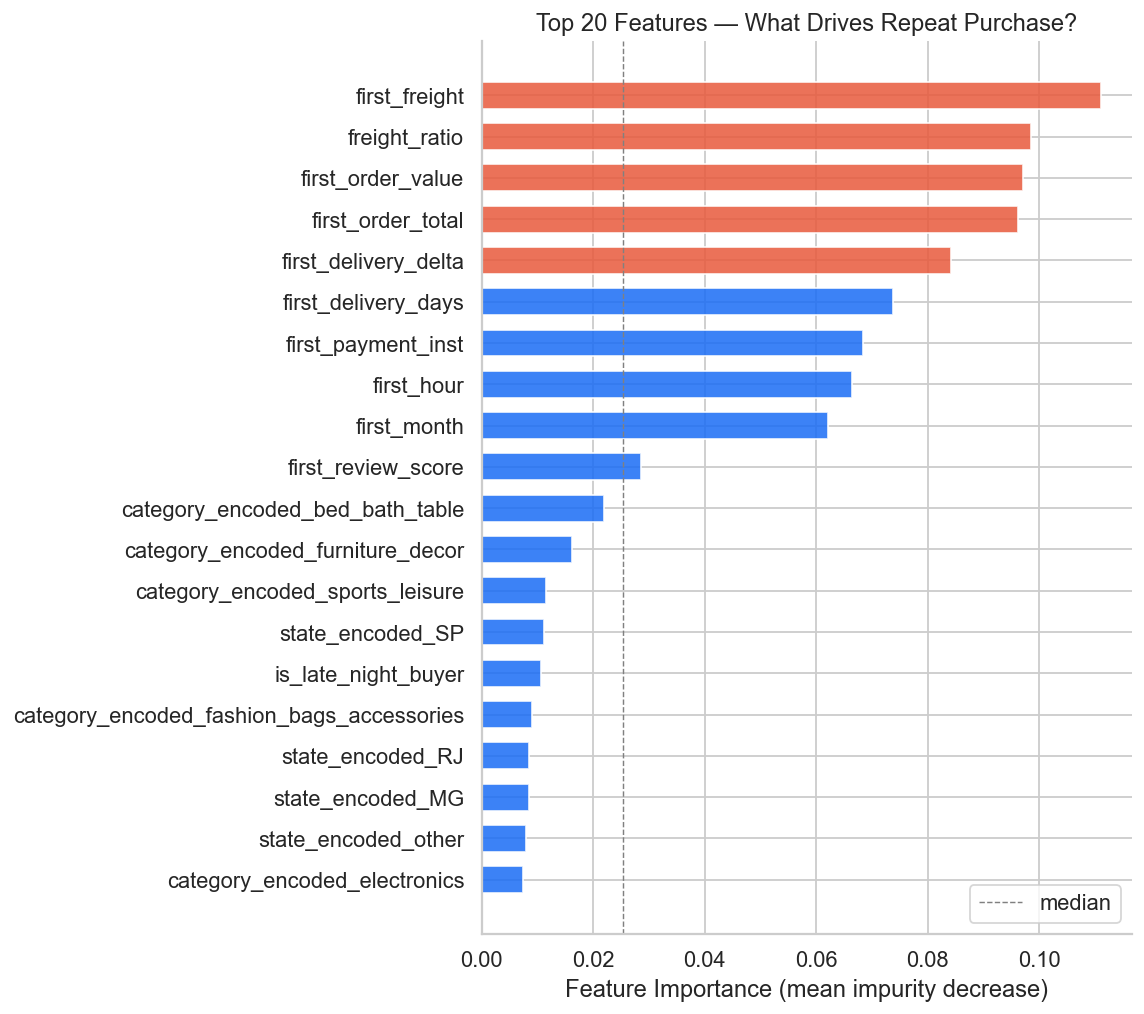

In [33]:
# ── 9.1  Built-in feature importance ─────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 8))
colors = [WARM if v > feat_imp.quantile(0.75) else ACCENT for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, alpha=0.85, height=0.65)
ax.set_xlabel('Feature Importance (mean impurity decrease)')
ax.set_title('Top 20 Features — What Drives Repeat Purchase?')
ax.axvline(feat_imp.median(), color='gray', linestyle='--', linewidth=0.8, label='median')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_feature_importance.png'), dpi=130, bbox_inches='tight')
plt.show()

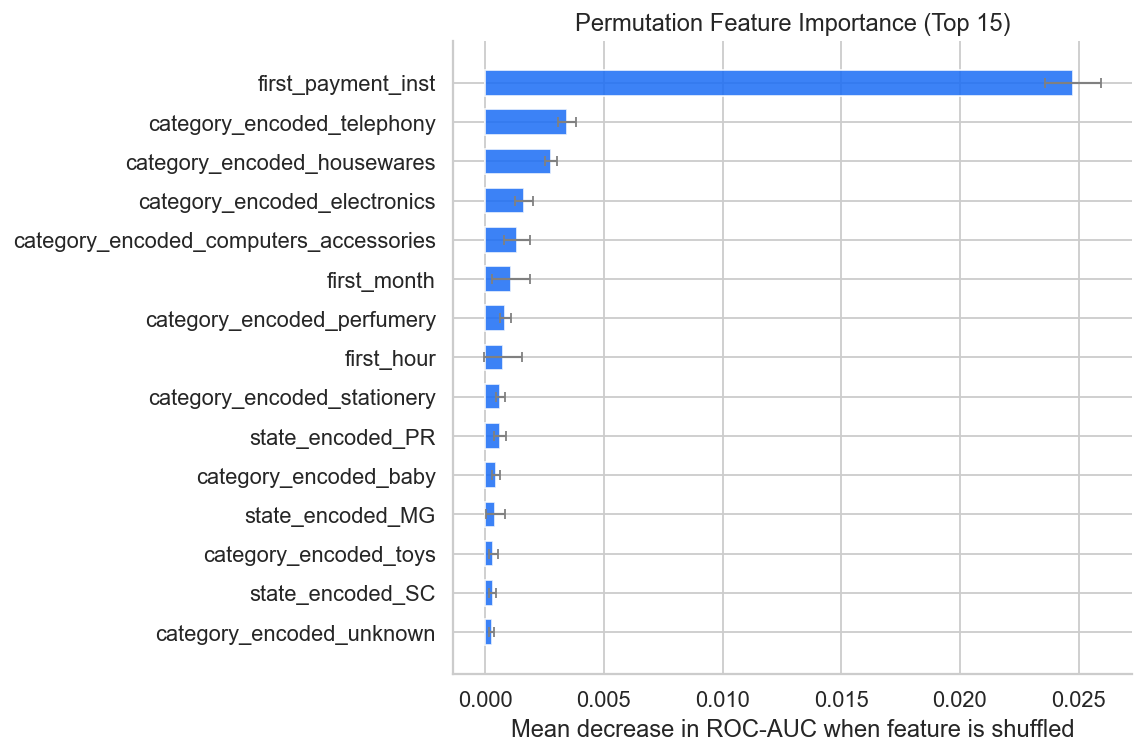


=== TOP 10 MOST IMPORTANT FEATURES ===
  first_payment_inst                   +0.02476 ± 0.00117
  category_encoded_telephony           +0.00345 ± 0.00038
  category_encoded_housewares          +0.00277 ± 0.00025
  category_encoded_electronics         +0.00163 ± 0.00037
  category_encoded_computers_accessories  +0.00134 ± 0.00053
  first_month                          +0.00108 ± 0.00080
  category_encoded_perfumery           +0.00085 ± 0.00023
  first_hour                           +0.00074 ± 0.00079
  category_encoded_stationery          +0.00063 ± 0.00019
  state_encoded_PR                     +0.00063 ± 0.00027


In [34]:
# ── 9.2  Permutation importance ───────────────────────────────────────────────
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    perm_imp['feature'][::-1], perm_imp['importance_mean'][::-1],
    xerr=perm_imp['importance_std'][::-1],
    color=ACCENT, alpha=0.85, height=0.65, capsize=3,
    error_kw={'elinewidth': 1.2, 'ecolor': 'gray'}
)
ax.set_xlabel('Mean decrease in ROC-AUC when feature is shuffled')
ax.set_title('Permutation Feature Importance (Top 15)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_permutation_importance.png'), dpi=130, bbox_inches='tight')
plt.show()

print('\n=== TOP 10 MOST IMPORTANT FEATURES ===')
for _, row in perm_imp.head(10).iterrows():
    print(f'  {row["feature"]:<35}  {row["importance_mean"]:+.5f} ± {row["importance_std"]:.5f}')

---
## 10. Prediction Probability Distribution

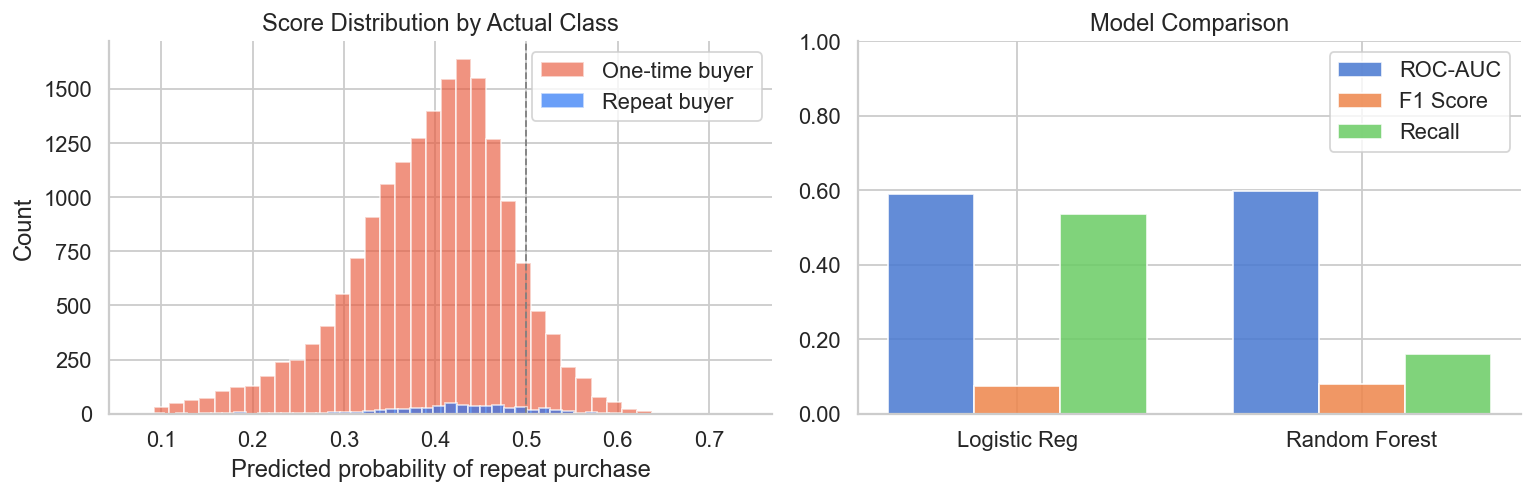

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Score distribution by actual class ────────────────────────────────────────
for val, label, color in [(0, 'One-time buyer', WARM), (1, 'Repeat buyer', ACCENT)]:
    mask = y_test == val
    axes[0].hist(rf_proba[mask], bins=40, alpha=0.65, label=label, color=color, edgecolor='white')

axes[0].set_xlabel('Predicted probability of repeat purchase')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution by Actual Class')
axes[0].legend()
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1)

# ── Model comparison bar chart ─────────────────────────────────────────────────
model_names = ['Logistic Reg', 'Random Forest']
metrics = {
    'ROC-AUC':  [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba)],
    'F1 Score': [f1_score(y_test, lr_preds),       f1_score(y_test, rf_preds)],
    'Recall':   [recall_score(y_test, lr_preds),    recall_score(y_test, rf_preds)],
}
x = np.arange(len(model_names))
width = 0.25
for i, (metric_name, vals) in enumerate(metrics.items()):
    axes[1].bar(x + i*width, vals, width, label=metric_name, alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0, 1)
axes[1].set_title('Model Comparison')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig_model_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## 11. Save the Model

In [36]:
# ── Save model, feature list, and predictions ─────────────────────────────────
joblib.dump(rf,           os.path.join(MODELS_DIR, 'churn_model.pkl'))
joblib.dump(feature_cols, os.path.join(MODELS_DIR, 'feature_cols.pkl'))
joblib.dump(feat_imp,     os.path.join(MODELS_DIR, 'feature_importance.pkl'))

preds_df = pd.DataFrame({
    'actual':      y_test.values,
    'predicted':   rf_preds,
    'prob_repeat': rf_proba
})
preds_df.to_csv(os.path.join(DATA_DIR, 'model_predictions.csv'), index=False)

feat_imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
feat_imp_df.to_csv(os.path.join(DATA_DIR, 'feature_importance.csv'), index=False)

print('=== SAVED FILES ===')
all_saved = [
    os.path.join(MODELS_DIR, 'churn_model.pkl'),
    os.path.join(MODELS_DIR, 'feature_cols.pkl'),
    os.path.join(MODELS_DIR, 'feature_importance.pkl'),
    os.path.join(MODELS_DIR, 'scaler.pkl'),
    os.path.join(DATA_DIR,   'model_predictions.csv'),
    os.path.join(DATA_DIR,   'feature_importance.csv'),
]
for f in all_saved:
    size_kb = os.path.getsize(f) / 1024 if os.path.exists(f) else 0
    status = '✓' if os.path.exists(f) else '✗ MISSING'
    print(f'  {status}  {f}  ({size_kb:.1f} KB)')

print('\nModel pipeline complete ✓')

=== SAVED FILES ===
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/models/churn_model.pkl  (16449.0 KB)
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/models/feature_cols.pkl  (1.1 KB)
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/models/feature_importance.pkl  (2.3 KB)
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/models/scaler.pkl  (2.9 KB)
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/model_predictions.csv  (425.9 KB)
  ✓  /Users/adnan/Desktop/python coding/brazilian data set/feature_importance.csv  (1.9 KB)

Model pipeline complete ✓
